# 🧠 Section 03. PyTorch 기초와 첫 CNN 구현
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- MNIST 데이터셋을 탐색하고 클래스별 샘플을 시각화한다
- LeNet-5를 PyTorch `nn.Module`로 직접 구현한다
- 학습 루프(train/val)를 완성하고 Loss·Accuracy 곡선을 시각화한다
- 오분류 샘플을 확인하고 Confusion Matrix를 분석한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | MNIST |
| 크기 | 70,000장 (train 60,000 / test 10,000) |
| 클래스 | 10개 (숫자 0~9) |
| 출처 | `torchvision.datasets.MNIST` |

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정

이 노트북은 `environment.yml`로 생성한 가상환경에서 실행합니다.

**환경이 아직 설정되지 않았다면:**
```bash
conda env create -f environment.yml
conda activate cnn-course
```

**Jupyter Lab 실행:**
```bash
jupyter lab
```

> GPU가 있는 경우 자동으로 CUDA를 사용합니다. CPU만 있어도 실습에 지장 없습니다.

In [2]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 109.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 108.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [25]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# ⚙️ 환경 설정 (반드시 가장 먼저 실행하세요)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 사용 디바이스: {device}")
print(f"✅ PyTorch 버전: {torch.__version__}")
print(f"✅ torchvision 버전: {torchvision.__version__}")

✅ 사용 디바이스: cuda
✅ PyTorch 버전: 2.7.0+cu128
✅ torchvision 버전: 0.22.0+cu128


In [5]:
# ─────────────────────────────────────────────
# 한글 폰트 자동 설정 (Mac / Linux / Colab 대응)
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 현재 설치된 폰트 이름 출력
font_list = [f.name for f in fm.fontManager.ttflist]

# 사용할 후보 폰트
candidate_fonts = [
    'AppleGothic',      # Mac
    'Malgun Gothic',    # Windows
    'NanumGothic',      # Linux/Colab
    'DejaVu Sans'
]

selected_font = None

for font in candidate_fonts:
    if font in font_list:
        selected_font = font
        break

# 폰트 적용
if selected_font:
    plt.rcParams['font.family'] = selected_font
    print(f"✅ 적용 폰트: {selected_font}")
else:
    print("❌ 사용 가능한 한글 폰트를 찾지 못했습니다.")

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

✅ 적용 폰트: DejaVu Sans


In [13]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 138 not upgraded.


In [14]:
import matplotlib as mpl
import shutil

cache_dir = mpl.get_cachedir()
print(cache_dir)

shutil.rmtree(cache_dir)
print("✅ matplotlib 캐시 삭제 완료")

/root/.cache/matplotlib
✅ matplotlib 캐시 삭제 완료


In [1]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ NanumGothic 적용 완료")

✅ NanumGothic 적용 완료


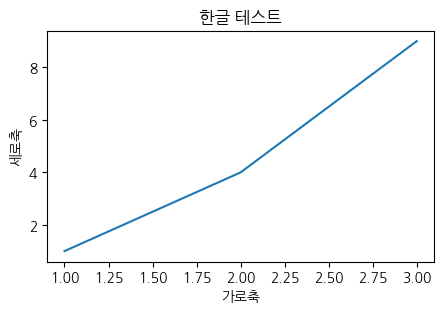

In [2]:
plt.figure(figsize=(5,3))
plt.title("한글 테스트")
plt.plot([1,2,3], [1,4,9])
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

In [27]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


## 📁 MNIST 데이터셋 소개

MNIST는 딥러닝의 Hello World입니다. 손글씨 숫자 0~9를 28×28 흑백 이미지로 담고 있습니다.

| 항목 | 내용 |
|------|------|
| 총 이미지 수 | 70,000장 |
| 훈련 세트 | 60,000장 |
| 테스트 세트 | 10,000장 |
| 이미지 크기 | 28×28 픽셀 (흑백) |
| 클래스 | 10개 (0, 1, 2, ..., 9) |

> 처음 실행 시 `./data` 디렉토리에 자동으로 다운로드됩니다.

---
## 실습 1. 데이터셋 탐색 및 시각화

### 📖 왜 데이터 탐색을 먼저 하는가?

모델을 설계하기 전에 데이터를 먼저 파악해야 합니다. 탐색으로 알 수 있는 것들:

- **이미지 형태**: 흑백인가 컬러인가? 크기는? → 입력 채널, 크기 결정에 영향
- **클래스 수**: 몇 개 클래스? → 출력 레이어 크기 결정
- **클래스 분포**: 불균형 없는가? → 손실 함수 선택에 영향

> 💡 **핵심 직관**  
> 요리를 시작하기 전에 재료를 확인하는 것처럼,  
> 모델을 만들기 전에 데이터를 확인합니다.  
> MNIST는 데이터 탐색이 쉬운 편이라 처음 학습하기에 좋습니다.

In [5]:
# ─────────────────────────────────────────────
# 1-1. 데이터셋 로드 및 기본 통계
# ─────────────────────────────────────────────

transform_basic = transforms.Compose([
    transforms.Resize((32, 32)),   # LeNet-5 입력 크기 맞춤
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 평균·표준편차
])

train_full = MNIST(root='./data', train=True,  download=True, transform=transform_basic)
test_set   = MNIST(root='./data', train=False, download=True, transform=transform_basic)

# 훈련/검증 분리 (50000/10000)
train_size = 50000
val_size   = len(train_full) - train_size
train_set, val_set = random_split(train_full, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

print(f"훈련 세트: {len(train_set):,}장")
print(f"검증 세트: {len(val_set):,}장")
print(f"테스트 세트: {len(test_set):,}장")
print(f"\n이미지 shape: {train_set[0][0].shape}")
print(f"클래스 수: {len(train_full.classes)}")
print(f"클래스 목록: {train_full.classes}")

훈련 세트: 50,000장
검증 세트: 10,000장
테스트 세트: 10,000장

이미지 shape: torch.Size([1, 32, 32])
클래스 수: 10
클래스 목록: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


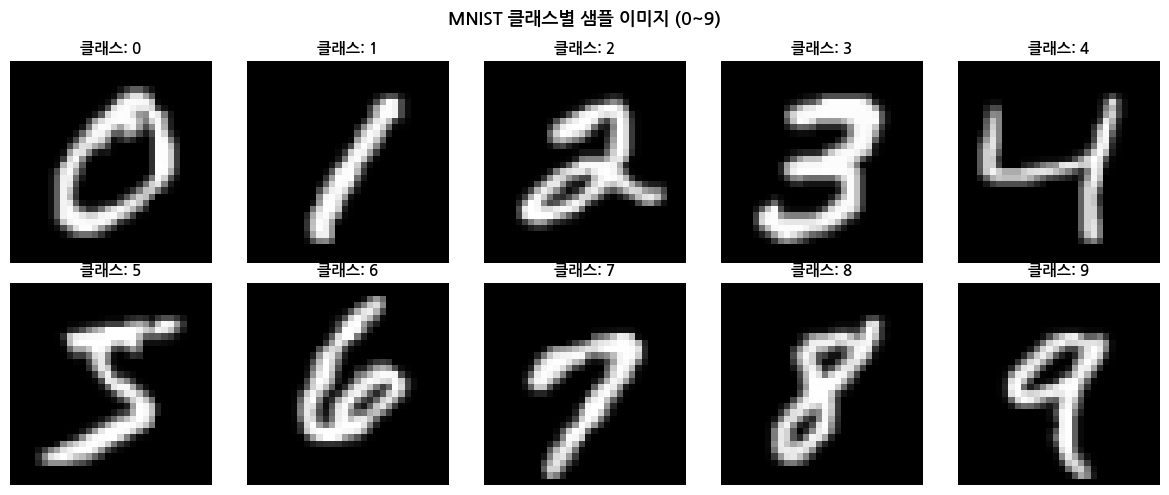

In [6]:
# ─────────────────────────────────────────────
# 1-2. 클래스별 샘플 시각화
# ─────────────────────────────────────────────

# 클래스별 샘플 1장씩 수집
class_samples = {}
for img, label in train_full:
    if label not in class_samples:
        class_samples[label] = img
    if len(class_samples) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, (label, img) in enumerate(sorted(class_samples.items())):
    ax = axes[idx // 5][idx % 5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"클래스: {label}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("MNIST 클래스별 샘플 이미지 (0~9)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

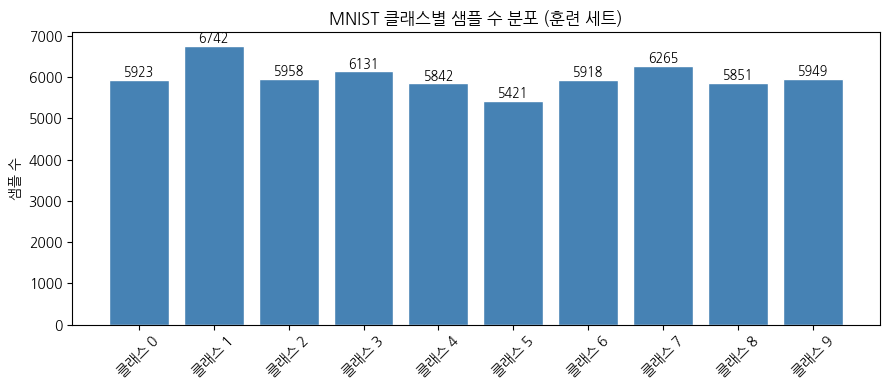

최소: 5421장 / 최대: 6742장 → 비교적 균형잡힌 데이터셋


In [7]:
# ─────────────────────────────────────────────
# 1-3. 클래스별 샘플 수 분포 확인
# ─────────────────────────────────────────────

labels = [label for _, label in train_full]
class_counts = np.bincount(labels)

plt.figure(figsize=(9, 4))
bars = plt.bar(range(10), class_counts, color='steelblue', edgecolor='white')
for bar, cnt in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(cnt), ha='center', va='bottom', fontsize=9)
plt.xticks(range(10), [f"클래스 {i}" for i in range(10)], rotation=45)
plt.ylabel("샘플 수")
plt.title("MNIST 클래스별 샘플 수 분포 (훈련 세트)")
plt.tight_layout()
plt.show()
print(f"최소: {class_counts.min()}장 / 최대: {class_counts.max()}장 → 비교적 균형잡힌 데이터셋")

---
## 실습 2. LeNet-5 구현

LeNet-5는 1998년 Yann LeCun이 설계한 CNN의 조상입니다.  
지금 기준으로는 단순하지만, **Conv→Pool→Conv→Pool→FC** 라는 CNN의 기본 뼈대를 처음 제시했습니다.

### 📖 LeNet-5 구조 한눈에 보기
```
입력 (1, 32, 32)
→ Conv(1→6, 5×5) → BN → ReLU → MaxPool(2×2)   # (6, 14, 14)
→ Conv(6→16, 5×5) → BN → ReLU → MaxPool(2×2)  # (16, 5, 5)
→ Flatten                                       # (400,)
→ Linear(400→120) → ReLU
→ Linear(120→84)  → ReLU
→ Linear(84→10)                                 # 클래스 점수
```

> 💡 **핵심 직관**  
> LeNet-5는 마치 눈이 물체를 인식하는 과정과 비슷합니다.  
> 앞쪽 레이어는 선·곡선 같은 단순한 특징을, 뒤쪽 레이어는 그 조합으로 숫자를 인식합니다.

> ⚠️ **주의**: 원본 LeNet-5는 Tanh + AvgPool을 사용하지만, 여기서는 성능이 더 좋은 ReLU + MaxPool + BatchNorm으로 수정해 구현합니다.

In [8]:
# ─────────────────────────────────────────────
# 2-1. LeNet-5 모델 정의
# ─────────────────────────────────────────────

class LeNet5(nn.Module):
    """
    LeNet-5 구현 (LeCun et al., 1998)
    원본 대비 수정: Tanh → ReLU, AvgPool → MaxPool (성능 향상)

    입력: (N, 1, 32, 32) → 출력: (N, num_classes)

    Args:
        num_classes (int): 분류할 클래스 수 (기본값: 10)
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),        # (1,32,32)→(6,28,28)
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # (6,28,28)→(6,14,14)

            nn.Conv2d(6, 16, kernel_size=5),       # (6,14,14)→(16,10,10)
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # (16,10,10)→(16,5,5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),            # 400→120
            nn.ReLU(inplace=True),
            nn.Linear(120, 84),                    # 120→84
            nn.ReLU(inplace=True),
            nn.Linear(84, num_classes),            # 84→10
        )

    def forward(self, x):
        """
        Args:
            x (Tensor): 입력 이미지 (N, 1, 32, 32)
        Returns:
            Tensor: 클래스 점수 (N, num_classes)
        """
        x = self.features(x)
        x = self.classifier(x)
        return x

model = LeNet5(num_classes=10).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n총 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

총 파라미터: 61,750
학습 가능 파라미터: 61,750


In [9]:
# ─────────────────────────────────────────────
# 2-2. Forward pass 검증 (학습 전 필수!)
# ─────────────────────────────────────────────
# ⚠️ 학습 전 반드시 더미 입력으로 shape를 확인하세요.
# FC 레이어 크기 오류는 이 단계에서 발견됩니다.

dummy = torch.randn(4, 1, 32, 32).to(device)
with torch.no_grad():
    out = model(dummy)

print(f"입력: {dummy.shape} → 출력: {out.shape}")
assert out.shape == (4, 10), "shape 불일치!"
print("✅ Forward pass 검증 성공!")

입력: torch.Size([4, 1, 32, 32]) → 출력: torch.Size([4, 10])
✅ Forward pass 검증 성공!


---
## 실습 3. 학습 루프 구현

모델을 학습시키려면 매 배치마다 같은 순서를 반복합니다.  
이 순서를 **절대 바꾸면 안 됩니다.**

### 📖 학습 루프의 4단계 순서
```
① optimizer.zero_grad()   ← 이전 배치 그래디언트 초기화
② outputs = model(inputs) ← 순전파 (예측)
③ loss.backward()         ← 역전파 (그래디언트 계산)
④ optimizer.step()        ← 가중치 업데이트
```

> 💡 **핵심 직관**  
> 시험을 본다고 생각하면: ①은 답안지를 새로 받는 것, ②는 문제를 푸는 것,  
> ③은 채점해서 어디가 틀렸는지 파악하는 것, ④는 틀린 부분을 고쳐 복습하는 것입니다.

> ⚠️ **CUDA out of memory**: 배치 크기를 줄이거나 (64→32) 이미지 크기를 확인하세요.  
> ⚠️ **Loss = NaN**: `optimizer.zero_grad()` 누락이 가장 흔한 원인입니다. 반드시 ①번 단계를 확인하세요.

In [10]:
# ─────────────────────────────────────────────
# 3-1. DataLoader 설정
# ─────────────────────────────────────────────
# DataLoader는 학습 데이터를 배치 단위로 나눠서 모델에 공급합니다.
#
# 📖 주요 파라미터
# - batch_size: 한 번에 처리할 이미지 수
#               크면 학습 빠르지만 메모리 많이 사용
#               작으면 메모리 적게 사용하지만 학습 느림
# - shuffle=True: 훈련 데이터는 매 에포크마다 순서를 섞어야 합니다
#                 안 섞으면 모델이 데이터 순서를 외워버릴 수 있음
# - num_workers: 데이터 로딩 병렬 처리 수 (CPU 코어 수에 따라 조절)
#
# ⚠️ CUDA out of memory: batch_size를 64 → 32 → 16으로 줄여보세요

BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"배치 크기:      {BATCH_SIZE}")
print(f"훈련 배치 수:   {len(train_loader)}  (= {len(train_set)} ÷ {BATCH_SIZE})")
print(f"검증 배치 수:   {len(val_loader)}")

images, labels = next(iter(train_loader))
print(f"\n배치 이미지 shape: {images.shape}  (배치, 채널, 높이, 너비)")
print(f"배치 레이블 shape: {labels.shape}  (배치,)")

배치 크기:      64
훈련 배치 수:   782  (= 50000 ÷ 64)
검증 배치 수:   157

배치 이미지 shape: torch.Size([64, 1, 32, 32])  (배치, 채널, 높이, 너비)
배치 레이블 shape: torch.Size([64])  (배치,)


In [11]:
# ─────────────────────────────────────────────
# 3-2. 손실 함수 및 옵티마이저 설정
# ─────────────────────────────────────────────
# ⚠️ CrossEntropyLoss는 내부적으로 Softmax를 포함합니다.
# → 모델 마지막 레이어에 별도로 Softmax를 추가하면 이중 적용이 됩니다!
# → 모델 출력은 반드시 raw 점수(logit)으로 끝내야 합니다.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"손실 함수: {criterion.__class__.__name__}")
print(f"  → Softmax + NLLLoss를 하나로 합친 것 (모델 출력에 Softmax 추가 금지!)")
print(f"옵티마이저: {optimizer.__class__.__name__}")
print(f"  → 학습률(lr): {optimizer.param_groups[0]['lr']}")
print(f"  → Adam은 각 파라미터마다 학습률을 자동 조절하는 옵티마이저입니다.")

손실 함수: CrossEntropyLoss
  → Softmax + NLLLoss를 하나로 합친 것 (모델 출력에 Softmax 추가 금지!)
옵티마이저: Adam
  → 학습률(lr): 0.001
  → Adam은 각 파라미터마다 학습률을 자동 조절하는 옵티마이저입니다.


### ✏️ TODO: `train_one_epoch()` 내부 역전파 코드 완성

In [12]:
# ─────────────────────────────────────────────
# TODO: train_one_epoch() 역전파 코드 완성
# ─────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    모델을 한 에포크 동안 훈련한다.

    Args:
        model     (nn.Module): 훈련할 모델
        loader    (DataLoader): 훈련 데이터로더
        criterion : 손실 함수
        optimizer : 옵티마이저
        device    : 연산 장치

    Returns:
        tuple: (평균 손실값, 정확도)
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # ① 그래디언트 초기화
        ___(  )  # 힌트: optimizer의 그래디언트를 초기화하는 메서드

        # ② 순전파
        outputs = model(images)

        # ③ 손실 계산
        loss = ___(outputs, labels)  # 힌트: criterion을 사용하세요

        # ④ 역전파 (그래디언트 계산)
        ___.___(  )  # 힌트: loss 객체의 backward 메서드

        # ⑤ 가중치 업데이트
        ___(  )  # 힌트: optimizer의 step 메서드

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

print("train_one_epoch()를 완성한 뒤 다음 셀을 실행하세요!")

train_one_epoch()를 완성한 뒤 다음 셀을 실행하세요!


In [13]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device):
    """모델을 한 에포크 동안 훈련한다."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()          # ① 그래디언트 초기화
        outputs = model(images)        # ② 순전파
        loss = criterion(outputs, labels)  # ③ 손실 계산
        loss.backward()                # ④ 역전파
        optimizer.step()               # ⑤ 가중치 업데이트
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

print("✅ 정답 함수 로드 완료!")

✅ 정답 함수 로드 완료!


In [14]:
# ─────────────────────────────────────────────
# 3-3. evaluate() 함수 정의
# ─────────────────────────────────────────────
# ⚠️ 평가 시 반드시 model.eval() + torch.no_grad() 두 가지를 함께 써야 합니다.
#
# model.eval()   → BatchNorm이 학습 통계 대신 누적 통계 사용
#               → Dropout이 비활성화 (모든 뉴런 사용)
# torch.no_grad() → 그래디언트 계산 비활성화 (메모리 절약, 속도 향상)
#
# 💡 직관: model.eval()은 "시험 모드"로 바꾸는 것,
#          no_grad()는 "채점을 위한 풀이 과정은 기록하지 않는 것"입니다.

def evaluate(model, loader, criterion, device):
    """
    모델 성능을 평가합니다. (그래디언트 계산 없음)

    Args:
        model     (nn.Module): 평가할 모델
        loader    (DataLoader): 검증/테스트 데이터로더
        criterion : 손실 함수
        device    : 연산 장치

    Returns:
        tuple: (평균 손실값, 정확도, 전체 예측값, 전체 정답값)
    """
    model.eval()   # ← 반드시 호출!
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():   # ← 반드시 호출!
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

print("✅ evaluate() 함수 정의 완료")
print("   model.eval() + no_grad() 세트를 항상 함께 사용합니다.")

✅ evaluate() 함수 정의 완료
   model.eval() + no_grad() 세트를 항상 함께 사용합니다.


In [15]:
# ─────────────────────────────────────────────
# 3-4. 전체 학습 실행
# ─────────────────────────────────────────────
# ⚠️ Loss = NaN 발생 시: 학습률을 줄이거나 입력 정규화를 확인하세요.

NUM_EPOCHS = 10
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

print(f"학습 시작 — {NUM_EPOCHS} 에포크")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch % 2 == 0 or epoch == 1:
        print(f"{epoch:>6} {train_loss:>12.4f} {train_acc*100:>9.2f}% {val_loss:>10.4f} {val_acc*100:>8.2f}%")

print("\n✅ 학습 완료!")

학습 시작 — 10 에포크
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       0.1960     94.36%     0.0886    97.29%
     2       0.0603     98.11%     0.0599    98.15%
     4       0.0378     98.80%     0.0448    98.60%
     6       0.0265     99.17%     0.0504    98.79%
     8       0.0196     99.37%     0.0413    98.88%
    10       0.0150     99.50%     0.0387    99.01%

✅ 학습 완료!


---
## 실습 4. 학습 결과 시각화 및 분석

학습이 잘 됐는지 확인하는 세 가지 방법을 순서대로 살펴봅니다.

| 시각화 | 확인하는 것 | 이상적인 모양 |
|---|---|---|
| Loss·Accuracy 곡선 | 과적합 여부 | Train↓ Val↓ 함께 감소 |
| Confusion Matrix | 어떤 클래스가 헷갈리는지 | 대각선만 밝음 |
| 오분류 샘플 | 실제 틀린 이미지 | 사람도 헷갈리는 모양 |

> 💡 **핵심 직관**  
> Loss 곡선에서 Train은 계속 낮아지는데 Val이 올라가기 시작하면 **과적합** 신호입니다.  
> 마치 시험 문제(train)만 외워서 실전(val)에서 못하는 것과 같습니다.

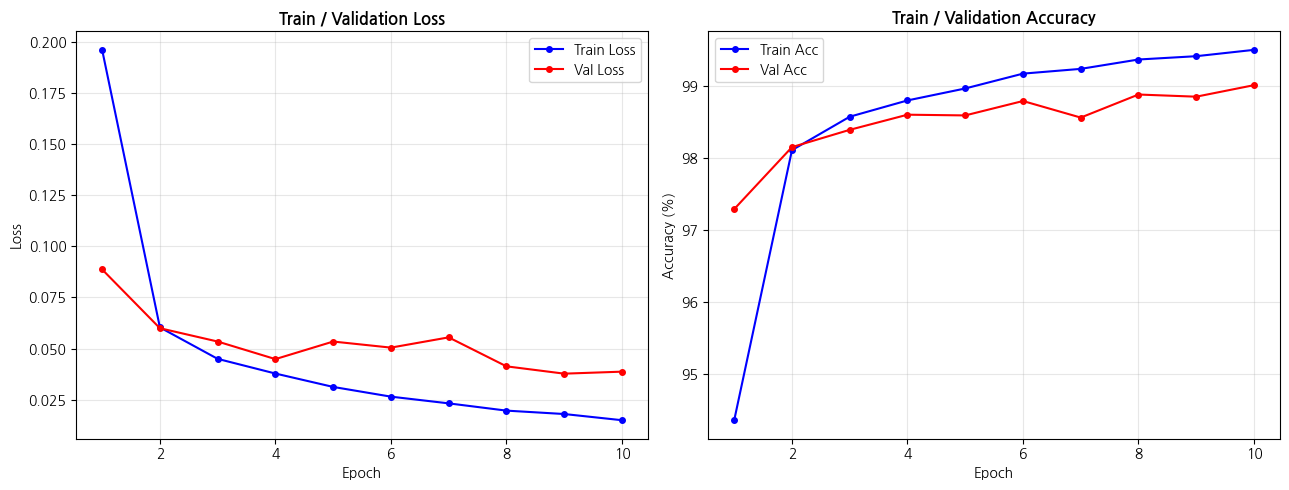

최종 검증 정확도: 99.01%


In [16]:
# ─────────────────────────────────────────────
# 4-1. Loss·Accuracy 곡선 시각화
# ─────────────────────────────────────────────

epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss 곡선
axes[0].plot(epochs, history["train_loss"], 'b-o', markersize=4, label="Train Loss")
axes[0].plot(epochs, history["val_loss"],   'r-o', markersize=4, label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train / Validation Loss", fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy 곡선
axes[1].plot(epochs, [a*100 for a in history["train_acc"]], 'b-o', markersize=4, label="Train Acc")
axes[1].plot(epochs, [a*100 for a in history["val_acc"]],   'r-o', markersize=4, label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Train / Validation Accuracy", fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"최종 검증 정확도: {history['val_acc'][-1]*100:.2f}%")

In [17]:
# ─────────────────────────────────────────────
# 4-2. 테스트 세트 최종 평가
# ─────────────────────────────────────────────

test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, device)
print(f"테스트 Loss:     {test_loss:.4f}")
print(f"테스트 정확도:   {test_acc*100:.2f}%")

테스트 Loss:     0.0313
테스트 정확도:   99.00%


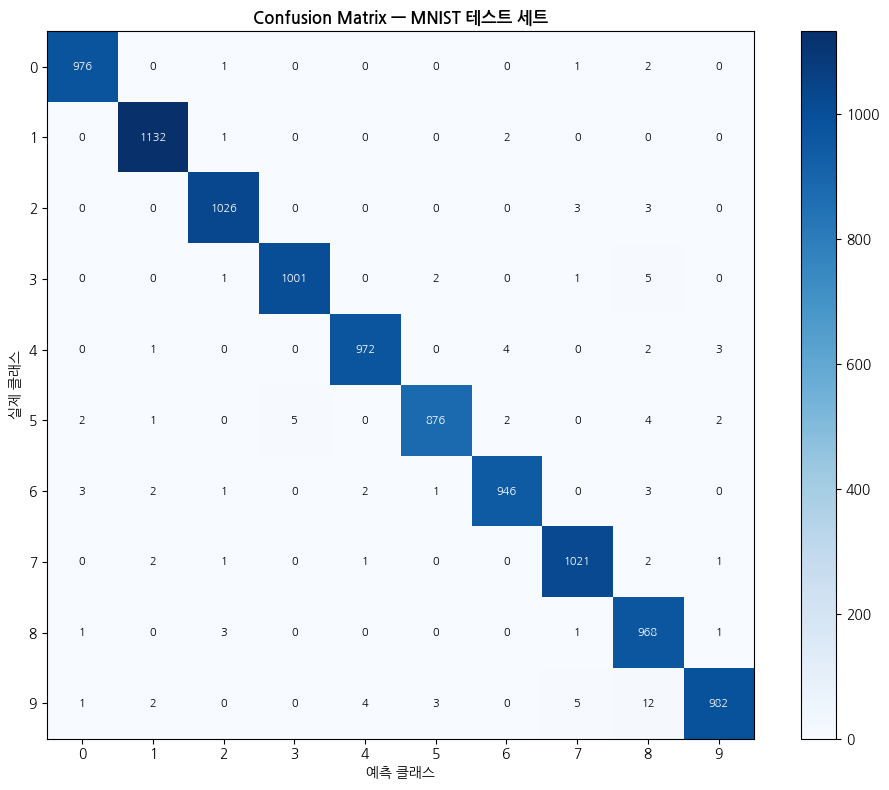


클래스별 정확도:
  클래스 0: 99.6%
  클래스 1: 99.7%
  클래스 2: 99.4%
  클래스 3: 99.1%
  클래스 4: 99.0%
  클래스 5: 98.2%
  클래스 6: 98.7%
  클래스 7: 99.3%
  클래스 8: 99.4%
  클래스 9: 97.3%


In [18]:
# ─────────────────────────────────────────────
# 4-3. Confusion Matrix 시각화
# ─────────────────────────────────────────────

cm = confusion_matrix(all_labels, all_preds)
class_names = [str(i) for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
ax.set_xlabel("예측 클래스"); ax.set_ylabel("실제 클래스")
ax.set_title("Confusion Matrix — MNIST 테스트 세트", fontweight='bold')

thresh = cm.max() / 2
for i, j in itertools.product(range(10), range(10)):
    ax.text(j, i, str(cm[i,j]), ha='center', va='center',
            color='white' if cm[i,j] > thresh else 'black', fontsize=8)

plt.tight_layout()
plt.show()

# 클래스별 정확도 출력
print("\n클래스별 정확도:")
for i in range(10):
    acc_i = cm[i,i] / cm[i].sum() * 100
    print(f"  클래스 {i}: {acc_i:.1f}%")

In [19]:
# ─────────────────────────────────────────────
# 4-4. 오분류 샘플 시각화
# ─────────────────────────────────────────────

# ✏️ 빈칸: 예측값과 실제값이 다른 샘플 인덱스 찾기
wrong_indices = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]
# 힌트: 예측이 실제와 같지 않은 (!=) 조건

print(f"전체 오분류 수: {len(wrong_indices)}개 / {len(all_labels)}개")
print(f"오분류율: {len(wrong_indices)/len(all_labels)*100:.2f}%")

전체 오분류 수: 100개 / 10000개
오분류율: 1.00%


In [20]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
wrong_indices = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]
print(f"오분류 수: {len(wrong_indices)}")

오분류 수: 100


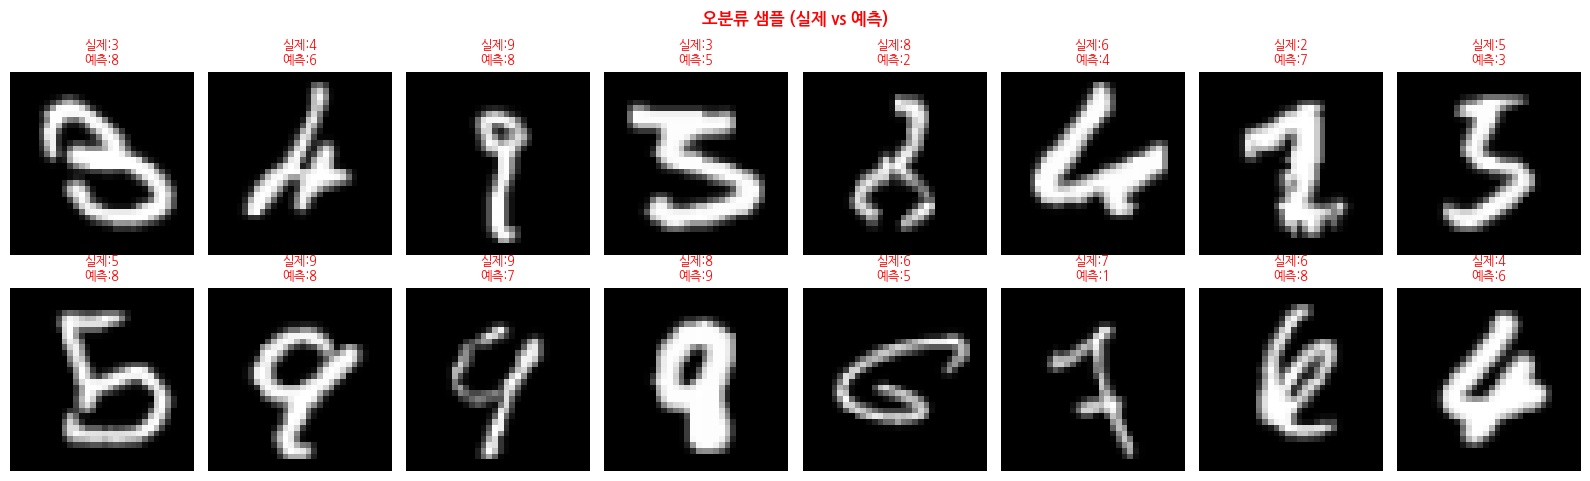

In [21]:
# 오분류 샘플 16개 시각화
wrong_samples = [(test_set[idx][0], all_labels[idx], all_preds[idx])
                 for idx in wrong_indices[:16]]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for ax, (img, true, pred) in zip(axes.ravel(), wrong_samples):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"실제:{true}\n예측:{pred}", fontsize=9,
                 color='red' if true != pred else 'black')
    ax.axis('off')

plt.suptitle("오분류 샘플 (실제 vs 예측)", fontsize=12, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

---
## 🚀 도전 과제

### 과제 1. 학습률 스케줄러 추가
`torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)`을 적용하여  
학습률 변화에 따른 성능 차이를 비교하세요.

### 과제 2. 더 깊은 CNN
LeNet-5에 Conv 레이어를 추가하거나 채널 수를 늘려 99% 이상의 테스트 정확도를 달성해보세요.

### 과제 3. 클래스별 정밀도·재현율
`sklearn.metrics.classification_report(all_labels, all_preds)`로  
클래스별 Precision, Recall, F1-Score를 출력하고 분석하세요.
